In [59]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [60]:
DATABASE = "nsrdb"
RECORD = "16265"
CHANNEL = 0
SAMPFROM = 0
SAMPLING_POINTS = 3600

In [61]:
record = wfdb.rdrecord(RECORD, pn_dir = DATABASE, sampfrom = SAMPFROM, sampto = SAMPFROM + SAMPLING_POINTS)
segmento_0 = record.p_signal[:, CHANNEL]
print("Segmento 0 guardado")

Segmento 0 guardado


In [62]:
x = record.p_signal[:, CHANNEL]
fs = record.fs

print("Número de muestras:", len(x))
print("Frecuencia de muestreo:", fs)

Número de muestras: 3600
Frecuencia de muestreo: 128


In [64]:
t = np.arange(len(x))/fs
print("Duración del segmento", t[-1], "segundos")

Duración del segmento 28.1171875 segundos


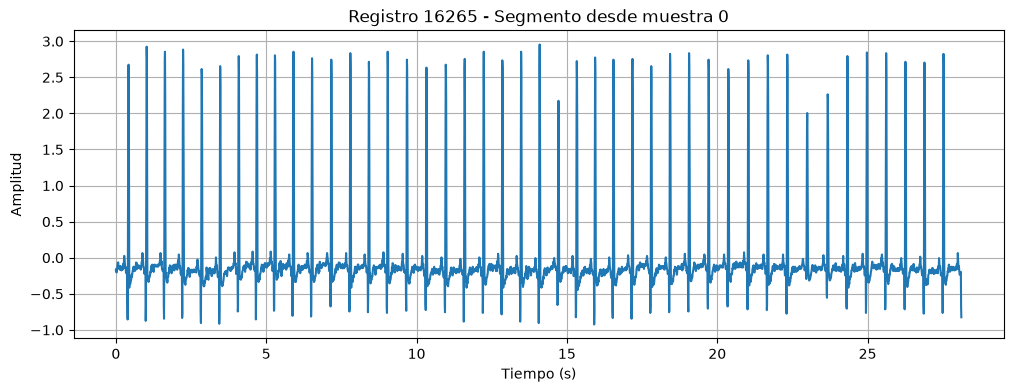

In [65]:
plt.figure(figsize=(12, 4))
plt.plot(t, x)
plt.title(f"Registro {RECORD} - Segmento desde muestra {SAMPFROM}")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

In [66]:
SAMPFROM = 5000

record = wfdb.rdrecord(RECORD, pn_dir = DATABASE, sampfrom = SAMPFROM, sampto = SAMPFROM + SAMPLING_POINTS)
segmento_5000 = record.p_signal[:, CHANNEL]

print("Segmento 5000 guardado")


Segmento 5000 guardado


In [67]:
print(len(segmento_0))
print(len(segmento_5000))

3600
3600


In [68]:
def calculate_fft(x, fs):
    N = len(x)
    x = np.fft.fft(x)
    f = np.fft.fftfreq(N, 1/fs)
    positive = f >= 0

    return f[positive], np.abs(x[positive])


In [69]:
f0, fft0 = calculate_fft(segmento_0, fs)
f5000, fft5000 = calculate_fft(segmento_5000, fs)
print("FFT calculadas")

FFT calculadas


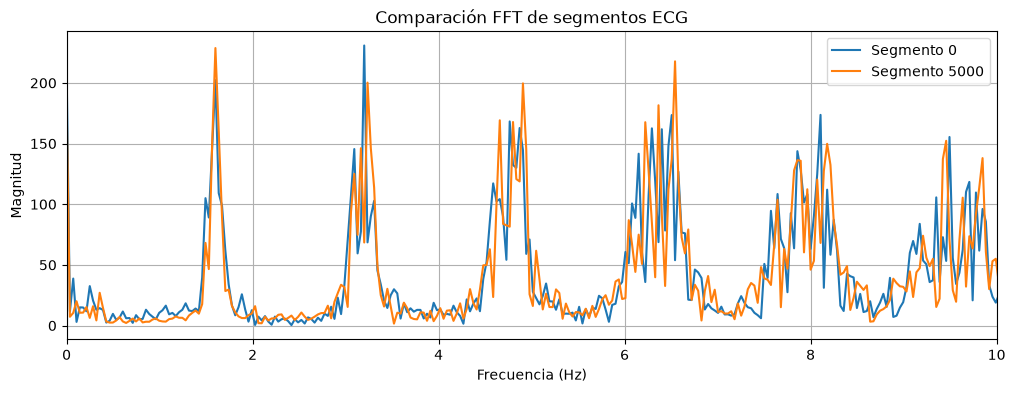

In [70]:
plt.figure(figsize=(12, 4))
plt.plot(f0, fft0, label='Segmento 0')
plt.plot(f5000, fft5000, label='Segmento 5000')
plt.xlim(0, 10)
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.title("Comparación FFT de segmentos ECG")
plt.legend()
plt.grid(True)
plt.show()

In [71]:
f_stft, t_stft, Zxx = signal.stft(segmento_5000, fs)
print("STFT calculada")

STFT calculada


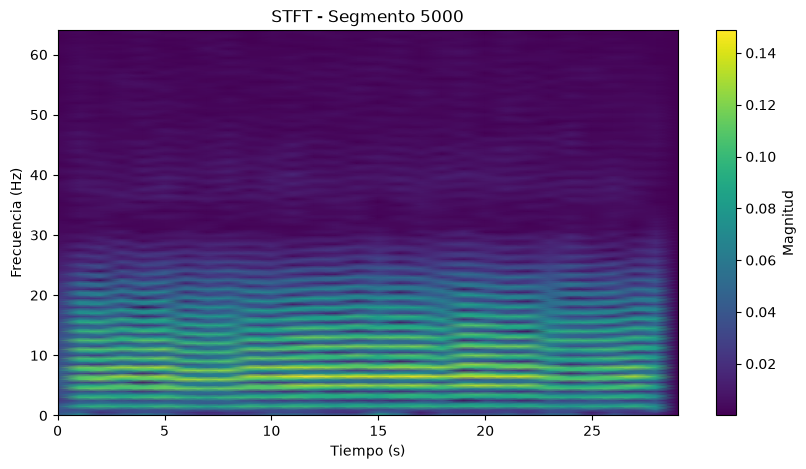

In [72]:
plt.figure(figsize=(10, 5))
plt.pcolormesh(t_stft, f_stft, np.abs(Zxx), shading='gouraud')
plt.xlabel("Tiempo (s)")
plt.ylabel("Frecuencia (Hz)")
plt.title("STFT - Segmento 5000")
plt.colorbar(label="Magnitud")
plt.show()

Conclusión ejercicio 2.1
Al modificar el segmento temporal de la señal ECG mediante el parametro SAMPFROM, se observó que la morfología de la señal se mantiene similar entre ambas regiones analizadas. Los complejos QRS conservaron su periodicidad y forma general. Al comparar los espectros obtenidos mediante FFT, se encontró que las componentes frecuenciales principales permanecen similares, aunque existen pequeñas variaciones en la magnitud debido a que se analizaron diferentes segmentos del registro. Finalmente, la STFT permitió analizar la evolución frecuencial respecto al tiempo, mostrando que la distribución de energía se mantiene estable y no aparecen eventos nuevos importantes en el segmento evaluado. 